# Imports

In [1]:
# PyTorch
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as nnFunc
from torchviz import make_dot
# General
import numpy as np
import matplotlib.pyplot as plt
# Optimizer
import torch.optim as optim
# pretty print
from pprint import pprint

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


## Dataset

This code uses the CIFAR-10 dataset.
(https://www.cs.toronto.edu/~kriz/cifar.html)

## 1. Transform setting
The original images are in PIL (0 to 255 for each pixel). First we convert it to a tensor format (0 to 1). Then to make the data to be zero centering, we make the range to be between -1 to 1. If we use the following equation for each data, we can make it zero centered:
\begin{equation}
  output = \frac{input - mean}{std}
\end{equation}
This is being done by setting the `mean` and `standard deviation` to be 0.5.

In [2]:
transform = transforms.Compose( [ transforms.ToTensor(),
                                  transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
                                ])

## 2. Making the training set
Now we load the actual dataset and make the training dataset.
1. Load CIFAR10 dataset (Download and prepare dataset)
    1. Put it in `./data` directory.
    2. Download it
    3. Do the specified transformation on the dataset
2. Create the data loader (pipelining settings)
    1. Brake it to batches with size of 32
    2. Shuffle the deck in every epoch
    3. Use 4 number of workers to make the training faster


In [3]:
batchSize = 256
numberOfWorkers = 8

trainSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                        train=True,
                                        download=True,
                                        transform = transform)
trainLoader = torch.utils.data.DataLoader(trainSet,
                                          batch_size=batchSize,
                                          shuffle=True,
                                          num_workers=numberOfWorkers,
                                          pin_memory=True)

d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 3. Making the test set
Now making the test set. The procedure is the same as making the training set with some minor modifications.

In [4]:
testSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                       train=False, # Diff
                                       download=True,
                                       transform=transform)
testLoader = torch.utils.data.DataLoader(testSet,
                                         batch_size=batchSize,
                                         shuffle=False, # Diff
                                         num_workers=numberOfWorkers,
                                         pin_memory=True)
viz_batchSize = 4
vizLoader = torch.utils.data.DataLoader(testSet, batch_size=viz_batchSize, shuffle=True)

## 4. The classes

In [5]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
pprint(classes)

('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## DEUBG1
Showing some of the images from the dataset.

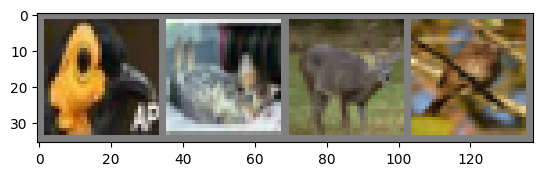

'bird  cat   deer  bird '


In [6]:
# functions to show an image
def imshow(img):
  img = img / 2 + 0.5 # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()
# get some random training images
dataiter = iter(vizLoader)
images, labels = next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
pprint(' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

## 5. Defining the CNN model

In [7]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1    = nn.Conv2d(3, 32, 3, padding=1)
    self.bn1      = nn.BatchNorm2d(32)
    self.conv2    = nn.Conv2d(32, 64, 3, padding=1)
    self.bn2      = nn.BatchNorm2d(64)
    self.pool     = nn.MaxPool2d(2, 2)
    self.lin1     = nn.Linear(64*8*8, 512)
    self.dropout  = nn.Dropout(0.3)
    self.lin2     = nn.Linear(512, 10)
  
  def forward(self, x):
    x = self.pool(nnFunc.relu(self.bn1(self.conv1(x))))
    x = self.pool(nnFunc.relu(self.bn2(self.conv2(x))))
    x = torch.flatten(x,1)
    x = nnFunc.relu(self.lin1(x))
    x = self.dropout(x)
    x = self.lin2(x)
    return x

## 6. Instansiating the CNN model

In [8]:
net = Net()

## 7. Move the model to GPU

In [9]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [10]:
net.to(device)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lin1): Linear(in_features=4096, out_features=512, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (lin2): Linear(in_features=512, out_features=10, bias=True)
)

## 7. Degine loss function and optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

## 8. Traing the network

In [12]:
epochs = 30
printFrequency = len(trainLoader) // 4
for epoch in range(epochs):  # loop over the dataset multiple times
  running_loss = 0.0
  correct = 0
  total = 0
  for i, data in enumerate(trainLoader, 0):
    # get the inputs; data is a list of [inputs, labels]
    inputs, labels = data[0].to(device), data[1].to(device)
    # zero the parameter gradients
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    # Accuracy Calculation
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    # Runnig loss
    running_loss += loss.item()
    # Printing
    if i % printFrequency == (printFrequency - 1):    # print every 2000 mini-batches
      accuracy = 100 * correct / total
      print(f'Epoch {epoch + 1} | Batch {i + 1}/{len(trainLoader)} | loss: {running_loss / printFrequency:.3f} | acc: {accuracy:.2f}%')
      # Reset all the counters
      running_loss = 0.0
      correct = 0
      total = 0

print('Finished Training')

Epoch 1 | Batch 49/196 | loss: 2.108 | acc: 29.55%
Epoch 1 | Batch 98/196 | loss: 1.546 | acc: 44.20%
Epoch 1 | Batch 147/196 | loss: 1.368 | acc: 50.37%
Epoch 1 | Batch 196/196 | loss: 1.274 | acc: 54.25%
Epoch 2 | Batch 49/196 | loss: 1.191 | acc: 57.40%
Epoch 2 | Batch 98/196 | loss: 1.108 | acc: 60.89%
Epoch 2 | Batch 147/196 | loss: 1.089 | acc: 61.25%
Epoch 2 | Batch 196/196 | loss: 1.036 | acc: 62.94%
Epoch 3 | Batch 49/196 | loss: 0.984 | acc: 64.88%
Epoch 3 | Batch 98/196 | loss: 0.944 | acc: 66.42%
Epoch 3 | Batch 147/196 | loss: 0.934 | acc: 67.17%
Epoch 3 | Batch 196/196 | loss: 0.939 | acc: 66.96%
Epoch 4 | Batch 49/196 | loss: 0.866 | acc: 69.38%
Epoch 4 | Batch 98/196 | loss: 0.855 | acc: 69.83%
Epoch 4 | Batch 147/196 | loss: 0.859 | acc: 69.98%
Epoch 4 | Batch 196/196 | loss: 0.850 | acc: 70.21%
Epoch 5 | Batch 49/196 | loss: 0.792 | acc: 72.16%
Epoch 5 | Batch 98/196 | loss: 0.793 | acc: 72.03%
Epoch 5 | Batch 147/196 | loss: 0.800 | acc: 71.61%
Epoch 5 | Batch 196/19

## 9. Test the network on the test data

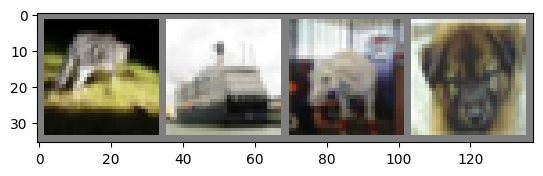

GroundTruth:  cat   ship  horse dog  


In [13]:
dataIter = iter(vizLoader)
images, labels = next(dataIter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

In [14]:
# Move the data to GPU
images, labels = images.to(device), labels.to(device)

# Now you can run it
outputs = net(images)
_, predicted = torch.max(outputs, 1)

# IMPORTANT: To print, move back to CPU
# Printing needs the labels to be on the CPU so Python can read them
print('Predicted: ', ' '.join(f'{classes[predicted[j].item()]:5s}' for j in range(len(predicted))))

Predicted:  horse ship  cat   dog  


## 10. Test the network on the whole dataset

In [15]:
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        
        outputs = net(images)
        
        # 1. Calculate the loss for this batch
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # 2. Calculate accuracy as before
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate the average loss over all batches
avg_test_loss = test_loss / len(testLoader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Loss: 1.2133
Test Accuracy: 71.77%


## 11. Check performance within each class

In [16]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 73.6 %
Accuracy for class: car   is 86.0 %
Accuracy for class: bird  is 57.4 %
Accuracy for class: cat   is 56.1 %
Accuracy for class: deer  is 69.1 %
Accuracy for class: dog   is 68.5 %
Accuracy for class: frog  is 72.4 %
Accuracy for class: horse is 79.0 %
Accuracy for class: ship  is 80.2 %
Accuracy for class: truck is 78.9 %


## Graphic

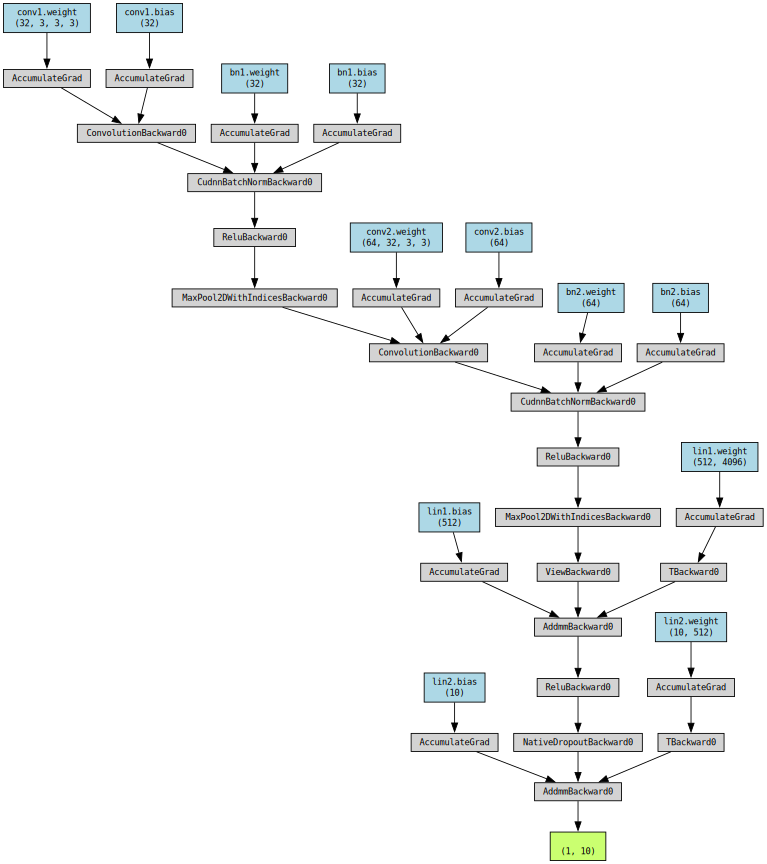

In [17]:
# Create a dummy input that matches your image size (1 image, 3 channels, 32x32)
dummy_input = torch.randn(1, 3, 32, 32).to(device)

# Run the input through your net
out = net(dummy_input)

# Generate the visualization
dot = make_dot(out, params=dict(net.named_parameters()))
dot.format = 'png'
dot.render("neural_network_graph")
dot

In [18]:
torch.onnx.export(net.cpu(), torch.randn(1, 3, 32, 32), "model.onnx")

C:\Users\kaveh\AppData\Local\Temp\ipykernel_27940\2844925536.py:1: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(net.cpu(), torch.randn(1, 3, 32, 32), "model.onnx")
W0315 02:25:17.998000 27940 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0315 02:25:18.000000 27940 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0315 02:25:18.002000 27940 Lib\site-packages\torch\onnx\_internal\exporter\_

[torch.onnx] Obtain model graph for `Net([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Net([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.


C:\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[1,3,32,32]>
            ),
            outputs=(
                %"linear_1"<FLOAT,[1,10]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"conv1.bias"<FLOAT,[32]>{Tensor(...)},
                %"conv2.weight"<FLOAT,[64,32,3,3]>{Tensor(...)},
                %"conv2.bias"<FLOAT,[64]>{Tensor(...)},
                %"lin1.weight"<FLOAT,[512,4096]>{TorchTensor(...)},
                %"lin1.bias"<FLOAT,[512]>{TorchTensor(...)},
                %"lin2.weight"<FLOAT,[10,512]>{TorchTensor(...)},
                %"lin2.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tenso